In [10]:
 #Import the Libraries.
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout


from contextlib import contextmanager



import pandas as pd

df = pd.read_csv('/content/BBhistory.csv.csv.csv')
print(df.head(20))

df.info()


df.tail()







          Date  Price  Open  High   Low  Volum Change %
0   12/30/2025   63.1  64.0  64.6  62.9   62.9   -1.10%
1   12/29/2025   63.8  65.5  65.5  63.2   63.2   -0.93%
2   12/28/2025   64.4  64.7  65.7  64.1   64.1   -0.46%
3   12/24/2025   64.7  64.9  64.9  64.0   64.0    0.78%
4   12/23/2025   64.2  64.4  65.6  64.0   64.0   -0.31%
5   12/22/2025   64.4  63.8  64.8  63.7   63.7    0.94%
6   12/21/2025   63.8  63.9  64.8  63.3   63.3   -0.16%
7   12/18/2025   63.9  64.4  64.9  63.7   63.7   -0.47%
8   12/17/2025   64.2  64.8  65.3  64.0   64.0   -0.77%
9   12/15/2025   64.7  66.4  66.4  64.4   64.4   -1.52%
10  12/14/2025   65.7  66.3  66.7  65.4   65.4   -1.20%
11  12/11/2025   66.5  67.4  70.0  66.0   66.0    0.15%
12  12/10/2025   66.4  66.5  67.0  66.3   66.3    0.15%
13  12/09/2025   66.3  66.0  67.0  65.8   65.8    0.61%
14  12/08/2025   65.9  65.4  66.0  65.3   65.3    0.46%
15  12/07/2025   65.6  66.3  66.3  65.5   65.5   -0.15%
16  12/04/2025   65.7  65.4  65.9  65.1   65.1  

,Date,Price,Open,High,Low,Volum,Change %
2605,01/08/2015,17.96,17.77,18.06,17.77,17.77,0.22%
2606,01/07/2015,17.92,18.15,18.15,17.87,17.87,0.28%
2607,01/06/2015,17.87,17.77,17.92,17.77,17.77,0.28%
2608,01/05/2015,17.82,17.77,17.92,17.63,17.63,0.79%
2609,01/01/2015,17.68,17.72,17.82,17.58,17.58,-0.51%


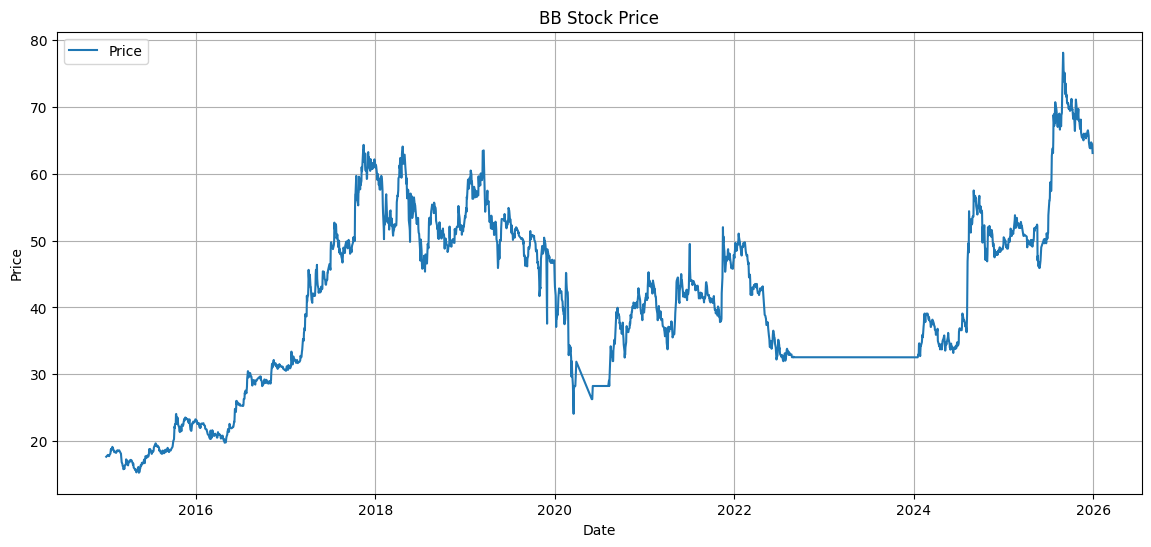

In [9]:
 #Import the Libraries.
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout


from contextlib import contextmanager


import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("/content/BBhistory.csv.csv.csv")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Plot the Price column
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Price'], label='Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BB Stock Price')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
import pandas as pd
import numpy as np

# Load CSV
df = pd.read_csv("/content/BBhistory.csv.csv.csv")

# Date column convert
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Convert Volume if K/M format exists
def convert_volume(x):
    x = str(x).replace(',', '')

    if 'K' in x:
        return float(x.replace('K', '')) * 1000
    elif 'M' in x:
        return float(x.replace('M', '')) * 1000000
    else:
        return float(x)

df['Volum'] = df['Volum'].apply(convert_volume)

# Technical Indicators
def add_technical_indicators(data):

    data = data.sort_index()

    # RSI
    delta = data['Price'].diff()
    gain = delta.where(delta > 0, 0).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

    RS = gain / loss
    data['RSI'] = 100 - (100 / (1 + RS))

    # MACD
    data['EMA12'] = data['Price'].ewm(span=12, adjust=False).mean()
    data['EMA26'] = data['Price'].ewm(span=26, adjust=False).mean()

    data['MACD'] = data['EMA12'] - data['EMA26']
    data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()

    # Bollinger Bands
    data['20_MA'] = data['Price'].rolling(window=20).mean()
    data['20_SD'] = data['Price'].rolling(window=20).std()

    data['Upper_Band'] = data['20_MA'] + (2 * data['20_SD'])
    data['Lower_Band'] = data['20_MA'] - (2 * data['20_SD'])

    # RSI Text
    data['RSI_Text'] = ''

    data.loc[data['RSI'] < 30, 'RSI_Text'] = 'Oversold'
    data.loc[data['RSI'] > 70, 'RSI_Text'] = 'Overbought'

    # Bollinger Band Text
    data['BB_Text'] = ''

    data.loc[data['Price'] > data['Upper_Band'], 'BB_Text'] = 'Above Upper Band'
    data.loc[data['Price'] < data['Lower_Band'], 'BB_Text'] = 'Below Lower Band'

    # Volume Moving Average
    data['Volum_MA'] = data['Volum'].rolling(window=20).mean()

    return data

# Apply indicators
df = add_technical_indicators(df)

# View result
print(df.head(20))

            Price   Open   High    Low  Volum Change %        RSI      EMA12  \
Date                                                                           
2015-01-01  17.68  17.72  17.82  17.58  17.58   -0.51%        NaN  17.680000   
2015-01-05  17.82  17.77  17.92  17.63  17.63    0.79%        NaN  17.701538   
2015-01-06  17.87  17.77  17.92  17.77  17.77    0.28%        NaN  17.727456   
2015-01-07  17.92  18.15  18.15  17.87  17.87    0.28%        NaN  17.757078   
2015-01-08  17.96  17.77  18.06  17.77  17.77    0.22%        NaN  17.788297   
2015-01-11  17.82  17.25  17.92  17.25  17.25   -0.78%        NaN  17.793174   
2015-01-12  17.77  17.82  17.96  17.63  17.63   -0.28%        NaN  17.789609   
2015-01-13  17.77  17.72  17.92  17.72  17.72    0.00%        NaN  17.786592   
2015-01-14  17.92  17.87  17.96  17.77  17.77    0.84%        NaN  17.807116   
2015-01-15  17.96  17.96  18.06  17.82  17.82    0.22%        NaN  17.830637   
2015-01-18  18.15  17.92  18.15  17.87  

         Date  Price      RSI14
0  2015-01-01  17.68        NaN
1  2015-01-05  17.82        NaN
2  2015-01-06  17.87        NaN
3  2015-01-07  17.92        NaN
4  2015-01-08  17.96        NaN
5  2015-01-11  17.82        NaN
6  2015-01-12  17.77        NaN
7  2015-01-13  17.77        NaN
8  2015-01-14  17.92        NaN
9  2015-01-15  17.96        NaN
10 2015-01-18  18.15        NaN
11 2015-01-19  18.39        NaN
12 2015-01-20  18.78        NaN
13 2015-01-21  18.63  79.141104
14 2015-01-22  18.87  81.818182
15 2015-01-25  18.78  76.373626
16 2015-01-26  19.16  80.000000
17 2015-01-27  19.11  77.674419
18 2015-01-28  19.01  73.755656
19 2015-01-29  18.87  73.755656


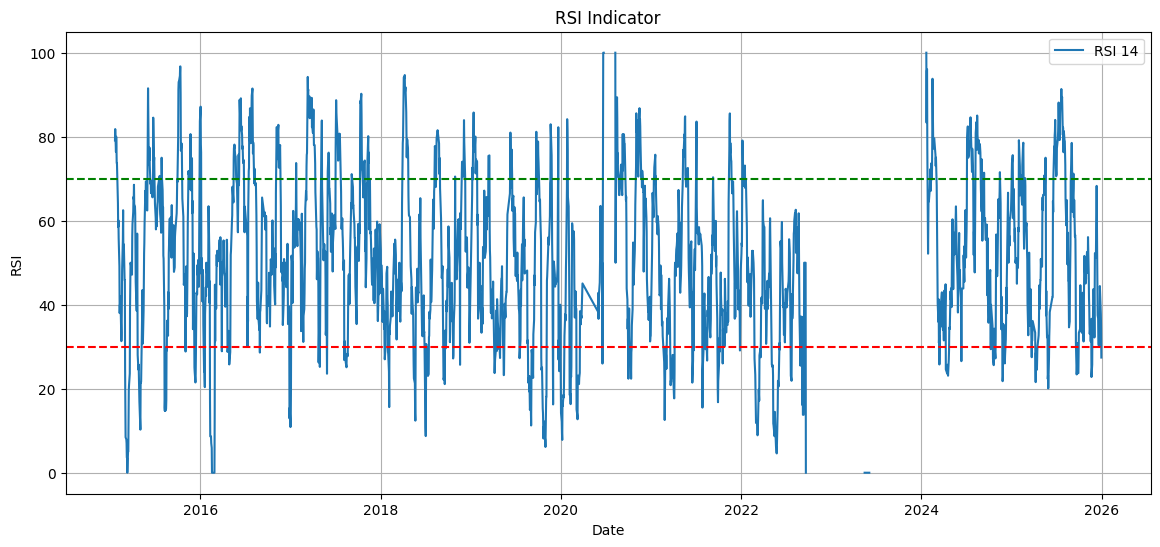

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/content/BBhistory.csv.csv.csv")

# Sort date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price = df['Price'].values

# =========================
# RSI (FIXED VERSION)
# =========================

def RSI(series, period=14):
    delta = np.diff(series, prepend=series[0])

    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)

    # rolling mean
    avg_gain = pd.Series(gain).rolling(period).mean()
    avg_loss = pd.Series(loss).rolling(period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi.values

# Calculate RSI
df['RSI14'] = RSI(price, 14)

# =========================
# RESULT CHECK
# =========================
print(df[['Date', 'Price', 'RSI14']].head(20))

# =========================
# PLOT RSI
# =========================
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['RSI14'], label='RSI 14')

plt.axhline(30, color='red', linestyle='--')
plt.axhline(70, color='green', linestyle='--')

plt.title("RSI Indicator")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.grid()
plt.show()

# =========================
# SAVE FILE
# =========================
df.to_csv("BBhistory_with_RSI.csv", index=False)

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load data
df = pd.read_csv("/content/BBhistory.csv.csv.csv")

# Sort date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# =========================
# USE Price instead of Close
# =========================
data = df['Price'].values.reshape(-1, 1)

# =========================
# Feature Scaling
# =========================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# =========================
# Train/Test split
# =========================
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# =========================
# Dataset creation function
# =========================
def create_dataset(data, time_step=60):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        Y.append(data[i + time_step, 0])

    return np.array(X), np.array(Y)

time_step = 60

X_train, Y_train = create_dataset(train_data, time_step)
X_test, Y_test = create_dataset(test_data, time_step)

# =========================
# Shape check
# =========================
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

# =========================
# Safety check
# =========================
if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("Not enough data. Reduce time_step or increase dataset size.")

# =========================
# Reshape for LSTM
# =========================
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train shape: (1765, 60)
Y_train shape: (1765,)
X_test shape: (723, 60)
Y_test shape: (723,)


In [24]:
import pandas as pd
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("/content/BBhistory.csv.csv.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# USE Price instead of Close
data = df['Price'].values.reshape(-1, 1)

# =========================
# SCALING
# =========================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# =========================
# TRAIN TEST SPLIT
# =========================
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# =========================
# DATASET CREATION
# =========================
def create_dataset(data, time_step=60):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:i+time_step, 0])
        Y.append(data[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60

X_train, Y_train = create_dataset(train_data, time_step)
X_test, Y_test = create_dataset(test_data, time_step)

# =========================
# RESHAPE FOR LSTM
# =========================
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# =========================
# MODEL
# =========================
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))

model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

# =========================
# COMPILE
# =========================
model.compile(optimizer='adam', loss='mean_squared_error')

# =========================
# TRAIN
# =========================
model.fit(X_train, Y_train, batch_size=64, epochs=100)

# =========================
# PREDICTION
# =========================
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# inverse transform
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

Y_train = scaler.inverse_transform(Y_train.reshape(-1, 1))
Y_test = scaler.inverse_transform(Y_test.reshape(-1, 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - loss: 0.0366
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - loss: 0.0059
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0042
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - loss: 0.0036
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.0037
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.0036
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - loss: 0.0032
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - loss: 0.0030
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - loss: 0.0030
Epoch 10/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - loss: 0.0027
Epoch 11/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.0025
Epoch 12/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.0025
Epoch 13/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - loss: 0.0025
Epoch 14/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 0.0025
Epoch 15/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5

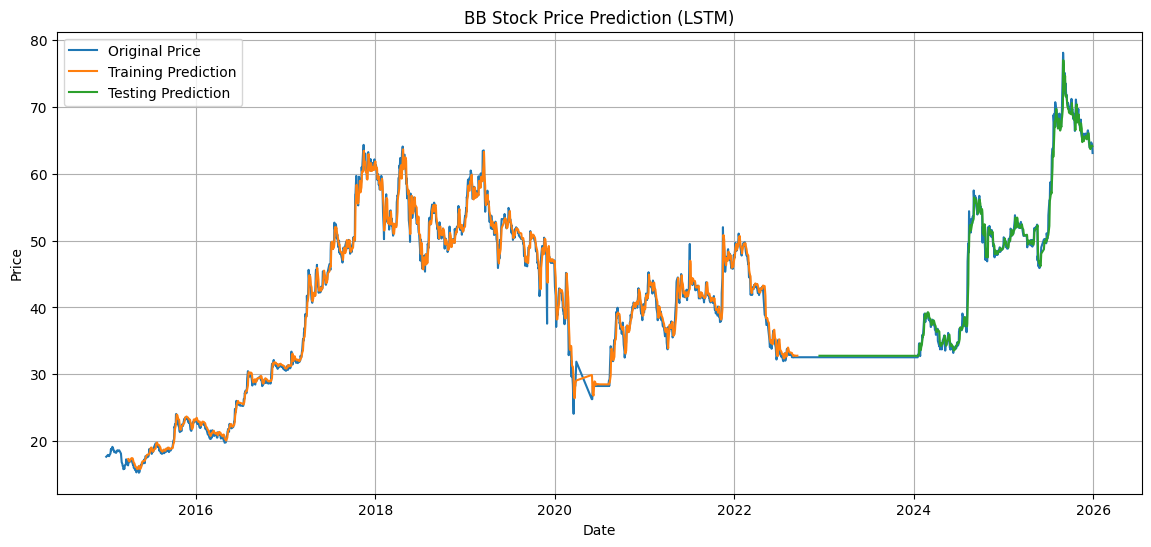

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# ORIGINAL DATA (Price)
# =========================
data = df['Price'].values.reshape(-1, 1)

# =========================
# TRAIN PLOT ARRAY
# =========================
train_plot = np.empty_like(data)
train_plot[:, :] = np.nan

train_plot[time_step:len(train_predict) + time_step, :] = train_predict

# =========================
# TEST PLOT ARRAY
# =========================
test_plot = np.empty_like(data)
test_plot[:, :] = np.nan

test_start = len(train_predict) + (time_step * 2) + 1
test_end = test_start + len(test_predict)

test_plot[test_start:test_end, :] = test_predict

# =========================
# PLOT
# =========================
plt.figure(figsize=(14,6))

plt.plot(df['Date'], data, label='Original Price')
plt.plot(df['Date'], train_plot, label='Training Prediction')
plt.plot(df['Date'], test_plot, label='Testing Prediction')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BB Stock Price Prediction (LSTM)')
plt.legend()
plt.grid()
plt.show()

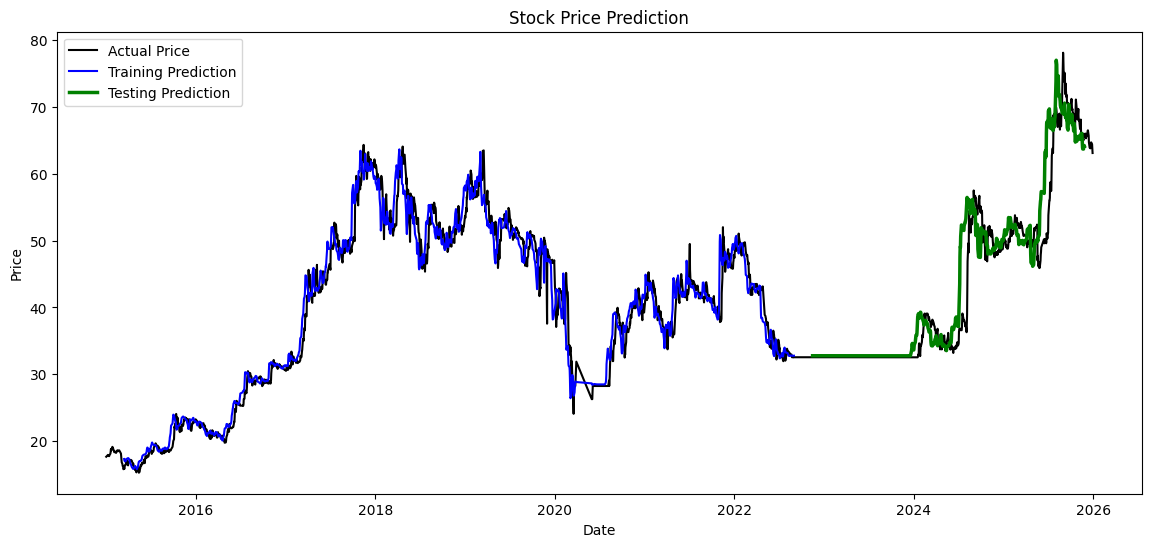

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("/content/BBhistory.csv.csv.csv")

# clean column names (VERY IMPORTANT)
df.columns = df.columns.str.strip()

# =========================
# 2. DATE PARSE (optional but recommended)
# =========================
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# =========================
# 3. TARGET COLUMN
# =========================
data = df['Price'].values
data = data.reshape(-1, 1)

# =========================
# 4. MODEL OUTPUT (must already exist)
# =========================
# train_predict -> your model output
# test_predict  -> your model output

train_predict = np.array(train_predict)
test_predict = np.array(test_predict)

# reshape (important)
train_predict = train_predict.reshape(-1, 1)
test_predict = test_predict.reshape(-1, 1)

# =========================
# 5. TIME STEP
# =========================
time_step = 50   # তোমার model অনুযায়ী change করো

# =========================
# 6. TRAIN PLOT
# =========================
train_plot = np.empty_like(data)
train_plot[:] = np.nan

train_plot[time_step:time_step + len(train_predict)] = train_predict

# =========================
# 7. TEST PLOT
# =========================
test_plot = np.empty_like(data)
test_plot[:] = np.nan

test_start = len(train_predict) + (time_step * 2) + 1
test_end = test_start + len(test_predict)

test_plot[test_start:test_end] = test_predict

# =========================
# 8. PLOT FINAL RESULT
# =========================
plt.figure(figsize=(14, 6))

plt.plot(df.index, data, label='Actual Price', color='black')
plt.plot(df.index, train_plot, label='Training Prediction', color='blue')
plt.plot(df.index, test_plot, label='Testing Prediction', color='green', linewidth=2.5)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Price Prediction')

plt.legend()
plt.show()